# TUS simulation safety parameter plots

In [1]:
import utils
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Make output folder
plot_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/TUS/acoustic_simulations/post-hoc'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

## Find mean ipa file in simulations folder

In [3]:
simulation_results_dataframe = '/Volumes/project/3025011.02/TUS_simulations/simulation_results.csv'

simulation_results_dataframe = pd.read_csv(simulation_results_dataframe)

print(simulation_results_dataframe)

     subject condition      target                 region  mean_Ipa      Isppa
0    sub-052  planning  target_1_1          amygdala_left  1.264882   3.715534
1    sub-053  planning  target_1_1          amygdala_left  1.462923   6.227767
2    sub-054  planning  target_1_1          amygdala_left  1.714427   7.493443
3    sub-055  planning  target_1_1          amygdala_left  1.245849   3.862284
4    sub-057  planning  target_1_1          amygdala_left  1.479996   5.064491
..       ...       ...         ...                    ...       ...        ...
98   sub-054  post-hoc  target_2_5   payam_dacc_left_mask  1.343156   9.060057
99   sub-057  post-hoc  target_2_5   payam_dacc_left_mask  2.745044  13.354380
100  sub-053  post-hoc  target_2_6  payam_dacc_right_mask  1.073770   7.116005
101  sub-054  post-hoc  target_2_6  payam_dacc_right_mask  2.278160   8.790071
102  sub-057  post-hoc  target_2_6  payam_dacc_right_mask  1.983277  10.706420

[103 rows x 6 columns]


# Mean Ipa in relevant target

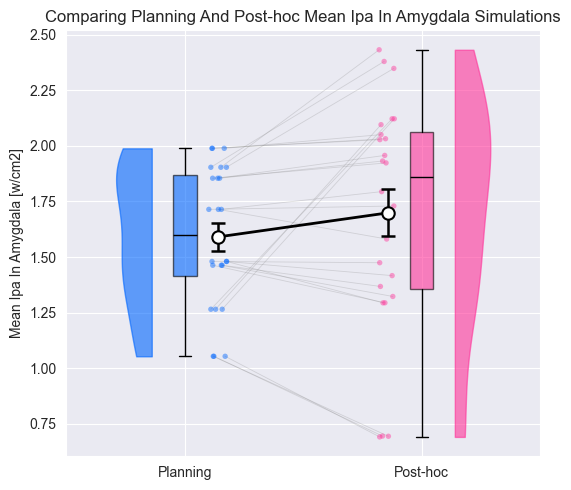

In [4]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_1')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='mean_Ipa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    output_dir=plot_dir,
    ylabel_name='mean Ipa in amygdala [w/cm2]',
    plot_name='comparing planning and post-hoc mean ipa in amygdala simulations'
);

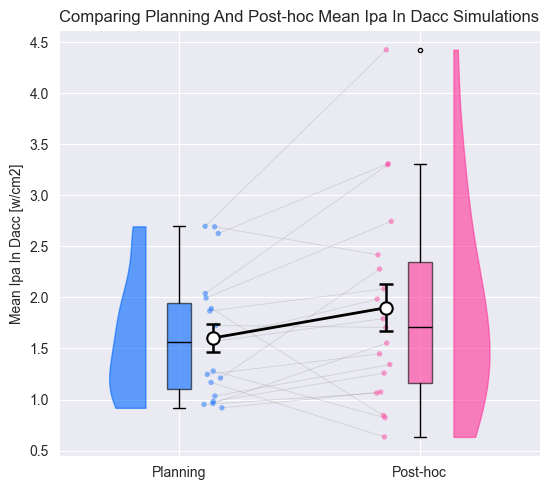

In [5]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_2')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='mean_Ipa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    output_dir=plot_dir,
    ylabel_name='mean Ipa in dacc [w/cm2]',
    plot_name='comparing planning and post-hoc mean ipa in dacc simulations'
);

# Isppa in relevant target

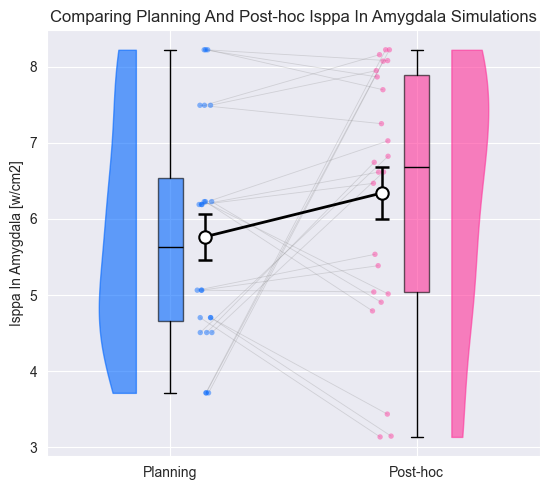

In [6]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_1')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='Isppa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    output_dir=plot_dir,
    ylabel_name='Isppa in amygdala [w/cm2]',
    plot_name='comparing planning and post-hoc isppa in amygdala simulations'
);

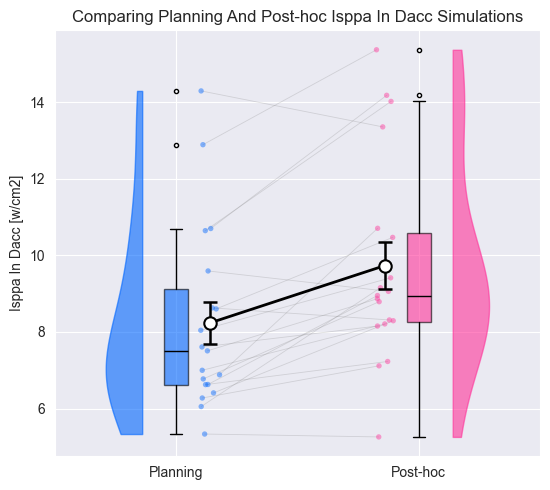

In [7]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_2')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='Isppa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    output_dir=plot_dir,
    ylabel_name='Isppa in dacc [w/cm2]',
    plot_name='comparing planning and post-hoc isppa in dacc simulations'
);